In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.svm import SVC
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import seaborn as sns
from sklearn.preprocessing import RobustScaler,OneHotEncoder
from sklearn.metrics import classification_report
from xgboost import XGBClassifier

In [2]:
df = pd.read_csv("bank_marketing_professional_columns.csv")
df

,CustomerAge,JobType,MaritalStatus,EducationLevel,HasCreditDefault,AccountBalance,HasHousingLoan,HasPersonalLoan,ContactType,LastContactDay,LastContactMonth,CallDurationSeconds,CampaignContacts,DaysSincePreviousContact,PreviousContacts,PreviousCampaignOutcome,TermDepositSubscribed
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no


In [3]:
df["TermDepositSubscribed"] = df["TermDepositSubscribed"].replace({"yes" : 1,"no":0})

C:\Users\bthar\AppData\Local\Temp\ipykernel_32084\3925536111.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["TermDepositSubscribed"] = df["TermDepositSubscribed"].replace({"yes" : 1,"no":0})


In [4]:
x = df.drop(columns = "TermDepositSubscribed")
y = df.TermDepositSubscribed

In [5]:
xtrain,  xtest, ytrain, ytest = train_test_split(x,y,random_state=42, train_size=0.8)

In [6]:
ytrain.value_counts()

TermDepositSubscribed
0    31970
1     4198
Name: count, dtype: int64

<Axes: >

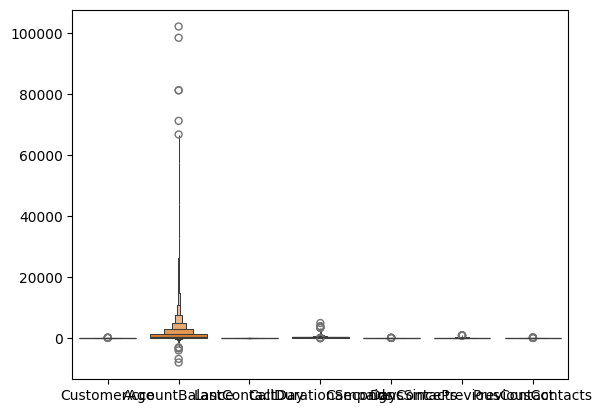

In [7]:
sns.boxenplot(x)

In [8]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   CustomerAge               45211 non-null  int64 
 1   JobType                   45211 non-null  object
 2   MaritalStatus             45211 non-null  object
 3   EducationLevel            45211 non-null  object
 4   HasCreditDefault          45211 non-null  object
 5   AccountBalance            45211 non-null  int64 
 6   HasHousingLoan            45211 non-null  object
 7   HasPersonalLoan           45211 non-null  object
 8   ContactType               45211 non-null  object
 9   LastContactDay            45211 non-null  int64 
 10  LastContactMonth          45211 non-null  object
 11  CallDurationSeconds       45211 non-null  int64 
 12  CampaignContacts          45211 non-null  int64 
 13  DaysSincePreviousContact  45211 non-null  int64 
 14  PreviousContacts      

In [9]:
num_cols = x.select_dtypes(include="number").columns
cat_cols = x.select_dtypes(include="object").columns

In [10]:
cat_cols.nunique()

9

In [11]:
preprocessing = ColumnTransformer(
    transformers=[
        ("scaler",RobustScaler(),num_cols),
        ("encoder",OneHotEncoder(),cat_cols)
    ]
)

In [12]:
main_pipe = Pipeline(
    steps = [
        ("pre",preprocessing),
        ("model",SVC())
    ]
)

In [13]:
main_pipe.fit(xtrain,ytrain)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaler', ...), ('encoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [14]:
ytrain_pred = main_pipe.predict(xtrain)
print(classification_report(ytrain,ytrain_pred))

              precision    recall  f1-score   support

           0       0.88      1.00      0.94     31970
           1       0.00      0.00      0.00      4198

    accuracy                           0.88     36168
   macro avg       0.44      0.50      0.47     36168
weighted avg       0.78      0.88      0.83     36168



c:\Users\bthar\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\bthar\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\bthar\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [15]:
ytest_pred = main_pipe.predict(xtest)
print(classification_report(ytest,ytest_pred))

              precision    recall  f1-score   support

           0       0.88      1.00      0.94      7952
           1       0.00      0.00      0.00      1091

    accuracy                           0.88      9043
   macro avg       0.44      0.50      0.47      9043
weighted avg       0.77      0.88      0.82      9043



c:\Users\bthar\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\bthar\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\bthar\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [ ]:
grid_cv = GridSearchCV(
    estimator= main_pipe,
    param_grid={
        "model__kernel": ["ploy","linear","rbf","sigmoid"],
        "model__C" :[0.001,0.01,0.1,10,50,100], 
        "model__gamma" :[0.01,0.1,10,100]
        # "model__class_weight" : ["balance"]
    },
    cv = 5,
    n_jobs= -1,
    verbose= 1
)

In [ ]:
grid_cv.fit(xtrain,ytrain)


Fitting 5 folds for each of 96 candidates, totalling 480 fits


In [ ]:
ytrain_pred = grid_cv.predict(xtrain)
print(classification_report(ytrain,ytrain_pred)) 

              precision    recall  f1-score   support

          no       0.88      1.00      0.94     31970
         yes       0.00      0.00      0.00      4198

    accuracy                           0.88     36168
   macro avg       0.44      0.50      0.47     36168
weighted avg       0.78      0.88      0.83     36168



c:\Users\bthar\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\bthar\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\bthar\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [ ]:
ytest_pred = grid_cv.predict(xtest)
print(classification_report(ytest,ytest_pred))

              precision    recall  f1-score   support

          no       0.88      1.00      0.94      7952
         yes       0.00      0.00      0.00      1091

    accuracy                           0.88      9043
   macro avg       0.44      0.50      0.47      9043
weighted avg       0.77      0.88      0.82      9043



c:\Users\bthar\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\bthar\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\bthar\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [ ]:
main_pipe = Pipeline(
    steps = [
        ("pre",preprocessing),
        ("model",XGBClassifier())
    ]
)

In [ ]:
main_pipe.fit(xtrain,ytrain)

ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1], got ['no' 'yes']